In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [15]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

## Weather

In [17]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())

In [18]:
CF_solar = PV_data.mean(axis = 1) # average all the years

In [16]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()


In [19]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

In [20]:
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
gas_price_pre_oct_2021.tail()

,GasDay,Created,BalanceType,Balance,ProductCode,greenZoneMin,greenZoneMax,YellowZoneMin,YellowZoneMax,GasBuyingPriceDKK,GasBuyPriceDescription,GasSellingPriceDKK,GasSellPriceDescription
15861,2022-09-30 00:00:00,2022-10-01 01:45:15,ESCB,3166032,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15862,2022-09-30 00:00:00,2022-09-30 22:45:23,ESCB,3537232,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15863,2022-09-30 00:00:00,2022-10-31 07:28:17,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15864,2022-09-30 00:00:00,2022-11-09 13:28:53,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15865,2022-09-30 00:00:00,2022-09-30 06:46:05,ESCB,-4450243,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN


In [21]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

In [22]:
gas_price_data = pd.read_excel(gas_file)

# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [23]:
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)

In [24]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

In [25]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [26]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

# Electrcity Prices

In [27]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

In [28]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [29]:
import pandas as pd
import numpy as np

def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    """
    Inputs:
        Elspotprices : pd.DataFrame (containing 'SpotPriceEUR')
        tariff_dict  : The multi-year dictionary (tariff_el_use)
        year         : int or str (e.g., 2021)
    """
    year_str = str(year)
    
    # --- 1. PREVENT TYPE ERROR: Select only the numeric column and filter year ---
    # We select only the 'SpotPriceEUR' column to avoid adding fees to string columns
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # Ensure it's numeric (handles any strange characters in the Excel)
    spot = pd.to_numeric(spot, errors='coerce').dropna()
    
    # --- 2. GET TARIFFS ---
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45  # Conversion: (øre/kWh * 10) / exchange_rate
    
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_weekday = hours.weekday < 5 
    
    # Define Hour Brackets
    is_low_hr  = hours.hour.isin(range(0, 6))   # 00:00 - 05:59
    is_peak_hr = hours.hour.isin(range(17, 21)) # 17:00 - 20:59
    is_day_hr  = hours.hour.isin(range(6, 24))  # 06:00 - 23:59

    # --- 3. APPLY NET TARIFF LOGIC (N1 MODEL 3.0) ---
    # Baseline is Low
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    
    # Apply High (Højlast) to all hours between 06:00 and 00:00
    net_tariff.loc[is_day_hr] = d["el_tariff_high"]
    
    # Apply Peak (Spidslast) ONLY in Winter AND on Weekdays during Peak Hours
    net_tariff.loc[is_winter & is_weekday & is_peak_hr] = d["el_tariff_peak"]

    # --- 4. CALCULATE FINAL PRICES ---
    fixed_fees_ore = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    
    # Buy Price = Spot + (Fixed Tariffs + DSO Net Tariff) converted to EUR/MWh
    buy_price = spot + (fixed_fees_ore + net_tariff) * DKK_to_EUR_MWh
    
    # Sell Price = Spot minus production/balancing fees
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price

In [30]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")

<Axes: xlabel='HourUTC'>

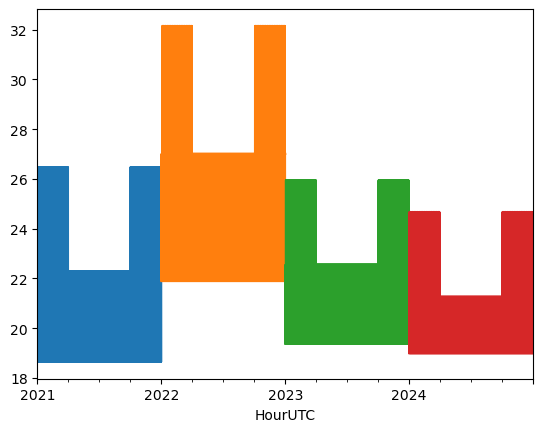

In [31]:
(import_price21 - elspotprices["SpotPriceEUR"]["2021"]).plot()
(import_price22 - elspotprices["SpotPriceEUR"]["2022"]).plot()
(import_price23 - elspotprices["SpotPriceEUR"]["2023"]).plot()
(import_price24 - elspotprices["SpotPriceEUR"]["2024"]).plot()

# Carbon Emissions Grid

In [32]:
import pandas as pd
import requests

def get_danish_co2_data(start_date="2023-01-01", end_date="2023-12-31"):
    # The API uses a 'Where' filter for dates. 
    # We target DK1 (West Denmark/Skive area)
    url = "https://api.energidataservice.dk/dataset/CO2Emis"
    params = {
        'filter': '{"PriceArea":["DK1"]}',
        'start': start_date,
        'end': end_date,
        'columns': 'Minutes5UTC,CO2Emission',
        'sort': 'Minutes5UTC ASC'
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Convert to DataFrame
    df = pd.DataFrame(data['records'])
    
    # Convert time to datetime objects and set as index
    df['Minutes5UTC'] = pd.to_datetime(df['Minutes5UTC'])
    df.set_index('Minutes5UTC', inplace=True)
    
    # The API provides 5-min data. Resample to HOURLY to match PyPSA
    # 'mean()' is used to get the average emission for that hour
    df_hourly = df['CO2Emission'].resample('h').mean()
    
    return df_hourly

# Example: Get data for your n23 year
co2_21_24 = get_danish_co2_data("2021-01-01", "2025-01-01")
print(co2_21_24.head())

# To add it to your PyPSA network:
# n23.generators_t.weight_carbon = co2_2023.values

Minutes5UTC
2020-12-31 23:00:00    190.833333
2021-01-01 00:00:00    196.000000
2021-01-01 01:00:00    168.166667
2021-01-01 02:00:00    160.083333
2021-01-01 03:00:00    161.083333
Freq: h, Name: CO2Emission, dtype: float64


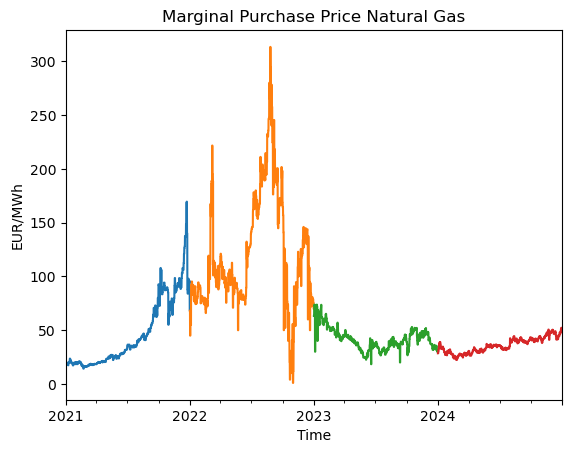

In [33]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2022"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2023"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2024"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.grid()
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.xlim("2021-01-01", "2024-12-31")
plt.title("Marginal Purchase Price Natural Gas")
plt.grid()

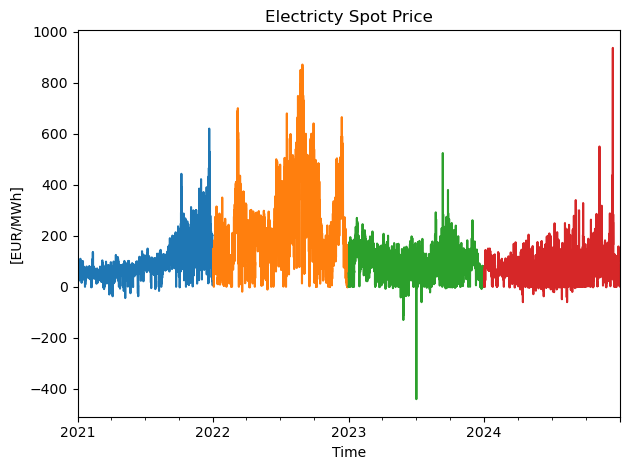

In [35]:
elspotprices["SpotPriceEUR"]["2021"].plot()
elspotprices["SpotPriceEUR"]["2022"].plot()
elspotprices["SpotPriceEUR"]["2023"].plot()
elspotprices["SpotPriceEUR"]["2024"].plot()
plt.ylabel("[EUR/MWh]")
plt.xlabel("Time")
plt.title("Electricty Spot Price")
#plt.legend(["2021", "2022", "2023", "2024"])
plt.tight_layout()
plt.show()

## Pypsa HeatMap

In [37]:
def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

## Network Start

In [421]:
def add_carriers(n):
   
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    n.add("Carrier","battery storage")
    n.add("Carrier","electric boiler")


    # 1. Define the Carriers
    #n.add("Carrier", "grid_import") 
    #n.add("Carrier", "grid_export") 
    
    n.add("Carrier","heat")
    n.add("Carrier","electricity")

    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    
    n.add("Carrier", "pellets", unit = "MW") 
    n.add("Carrier", "CO2", unit = "t/h") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis", unit = "MW")
    
    n.add("Carrier", "hydrogen")
    n.add("Carrier", "electrolysis")
   
    n.add("Carrier", "methanol")
    n.add("Carrier", "methanolisation")

    #n.add("Carrier", "RONDO_heat")
    
    n.add("Carrier", "digestate")
    
    n.add("Carrier", "biomass", unit = "t/h")
    n.add("Carrier", "biochar")
    n.add("Carrier", "methane")

In [390]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "Greenlab" , # Greenlab , EuroWind
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 30)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "Greenlab",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

In [422]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=False,
          p_nom = 84, # GCP limit
          efficiency=1.0,
          marginal_cost=0,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="Greenlab",   # [EuroWind or Greenlab]
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          #e_nom = 130e3, # MWh 
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="Greenlab",   # [EuroWind or Greenlab]
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

In [392]:
def add_battery(n,P_nom, max_t, cyclic_operation = False):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="Greenlab",  # Use your electricity bus name {EuroWind, Greenlab}
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [423]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        #e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = e_nom_store,
        e_cyclic=False,
        standing_loss= 1.2/100, # 1.2% per hour
        carrier = "heat",
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        p_nom_max = p_nom_charge, 
        # p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_MT",
        #p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        p_nom_max = p_nom_discharge,
        efficiency=0.90*0.8, # Including Efficency of Heat Exchanger here
        carrier = "heat",
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [424]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        #p_nom = 10, # MW,
        p_nom_extendable = True,
        p_nom_min = 10,
        p_nom_max = 10,
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        marginal_cost = costs.at["electric boiler steam","marginal_cost"])

co2 emissions NG:
- 0.202 tCo2/MWh_th {Primary Fuel Intensity}
- Carbon Tax 70 EUR/t_co2 emitted

In [395]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        marginal_cost = NG_price + 0.202*CO2tax + 1.007, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,) 

- carbon sequestered from biochar

In [425]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t

    n.add("Store",
    "pellets store",
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = True)
    
    # straw pellets cost from 35 - 82 EUR/ton
    # LHV_pellets = 16 MJ/kg
    

    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="biochar",
        bus3 = "Greenlab",
        p_nom_extendable=False,
        p_nom=2,
        efficiency = 8.5/20, # MW , 8.2/21.7 , Heat High Temp
        efficiency2 = 9/20, # MW , 10.1/21.7 , Biochar
        efficiency3 = -0.02, # MW, auxillary power (2 %)
        carrier="pyrolysis",
        capital_cost=costs.at["biochar pyrolysis","capital_cost"],
        marginal_cost = costs.at["biochar pyrolysis","marginal_cost"]) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom = 1, # MW  
        p_nom_extendable = False,
        marginal_cost= -0.313*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom = 8e3,
        e_nom_extendable=False,
        e_cyclic=False,
        carrier="biochar")

In [370]:
costs.at["biogas upgrading", "capital_cost"],costs.at["biogas", "capital_cost"],

(56666.87115954434, 206764.5790364669)

In [426]:
    # Fixed Load for Biogas Plant
def biogas_plant_simple(n):

        n.add("Store","Biomass Store",
            bus = "Biogas_Feedstock",
            e_nom = 500000 ,
            e_initial = 500000, # t
            e_min_pu = 0,
            e_cyclic = False,
            carrier = "biomass",
            marginal_cost = 21) # EUR/t } Glycerine + Energy Crops + Animal Slurry

        n.add("Link",
            "BiogasPlant",
            bus0 = "Biogas_Feedstock", # input: Feedstock
            bus1 = "Greenlab", # input: electrcity
            bus2 = "Heat_MT", # input: heat
            bus3 = "pellets", # output: Pellets
            bus4 = "Biogas", # ouptut: CH4 
            bus5 = "Co2", # output: Co2
            carrier = "BiogasPlant",
            p_nom_extendable = True,
            #p_nom = 30*2.09, # t/h
            #p_min_pu = 25/30,
            p_nom_max = 63, 
            p_min_pu = 0,
            p_max_pu = 1,
            capital_cost = costs.at["biogas","capital_cost"],
            marginal_cost = costs.at["biogas", "marginal_cost"],
            efficiency =  -(0.02 + 0.008 + 0.02)/2.09, # el input (MW) } auxillary + dewatering + upgrading 
            efficiency2 = -(0.05 + 0.1)/2.09, # heat input (MW) } auxillary + upgrading
            efficiency3 =  0.12/2.09, # Pellets output (MW)) 
            efficiency4  = 1/2.09,  # Biogas (CH4) output (MW)
            efficiency5 = 0.1/2.09, # co2 (t/h)
        )

        
        n.add("Store", "Biogas_Store",
            bus = "Biogas",
            marginal_cost = 0,
            carrier = "methane",
            capital_cost = costs.at["methane storage tank incl. compressor", "capital_cost"],
            e_nom_extendable = True,
            )

        n.add("Store", "Co2_Store",
        bus = "Co2",
        carrier = "CO2",
        e_nom_extendable = True,
        #e_nom = 500e3 # t
        )

        # 200 GWh, Annualy
        n.add("Load", "CH4_Demand",
        bus = "Biogas",
        p_set = 200*1e3/len(n.snapshots),
        carrier = "methane")

In [427]:
"Adding Electrolyser"
def add_electrolyser(n, P_elec):
    n.add("Link",
    "Electrolyser",
    bus0 = "Greenlab",
    bus1 = "H2_Bus",
    p_nom = P_elec,
    p_min = P_elec,
    p_max = P_elec,
    p_nom_extendable = True,
    carrier = "electrolysis",
    p_min_pu = 0.15,
    #p_nom_min = , 
    #p_nom_max = ,
    capital_cost = costs.at["Alkaline electrolyzer medium size", "capital_cost"],
    marginal_cost = costs.at["Alkaline electrolyzer medium size", "marginal_cost"],
    efficiency = 0.6,)

    n.add("Store",
    "H2_Storage",
    bus = "H2_Bus",
    capital_cost = costs.at["hydrogen storage tank type 1 including compressor", "capital_cost"],
    e_nom_extendable = True,
    carrier = "hydrogen",
    e_cylic = False)

In [428]:
def add_methanolisation(n, p_min):
  
    n.add("Link",
     "methanolisation",
     bus0 = "H2_Bus",
     bus1 = "methanol_bus",
     bus2 = "Greenlab",
     bus3 = "Co2",  # Co2 from byproduct of biogas plant
     #p_nom = 10, # 10 MW methanol plant,
     p_nom_extendable = True,
     p_min_pu = p_min,
     carrier = "methanolisation",
     capital_cost = costs.at["methanolisation", "capital_cost"]*eff_h2,
     efficiency = eff_h2, # 0.87 , methanol output 
     efficiency2 = -costs.at["methanolisation", "electricity-input"]*eff_h2, # - 0.23 , electricty input
     efficiency3 = -costs.at["methanolisation", "carbondioxide-input"]*eff_h2 , # - 0.218 t/h , Co2 input
     )
 
    n.add("Store",
    "methanol storage",
    bus="methanol_bus",
    carrier="methanol",
    capital_cost=costs.at["General liquid hydrocarbon storage (crude)", "capital_cost"] / (15.6 * 1000 / 3600),
    e_nom_extendable=True,
    e_cyclic=False,)

In [404]:
def rondo_constraints(n, snapshots):
        """
        Custom constraint to keep Rondo Power = Ratio * Rondo Energy
        """
        model = n.model
        # Get variables
        e_nom = model.variables["Store-e_nom"].loc["Rondo_Concrete_Heat_Storage"]
        p_nom_charge = model.variables["Link-p_nom"].loc["El_to_TES_Rondo"]
        p_nom_discharge = model.variables["Link-p_nom"].loc["TES_Rondo_to_Heat_Bus_Skive"]

        # Add constraints (Ratio based on 24/100 and 7/100)
        model.add_constraints(p_nom_charge - 0.24 * e_nom == 0, name="Rondo_charge_ratio")
        model.add_constraints(p_nom_discharge - 0.07 * e_nom == 0, name="Rondo_discharge_ratio")

In [429]:
def build_network(CO2_tax, p_import, p_export, NG_price, horizon, overlap):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    
    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    add_carriers(n)

    n.add("Carrier","BiogasPlant")
    n.add("Carrier", "methane_demand", units = "MW")


    n.add("Bus", "Greenlab", carrier="electricity")

    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")

    n.add("Bus", "NG", carrier="gas")

     # Heat & Solids
    #n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    #n.add("Bus", "Digestate", carrier = "digestate")
    
    #n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    

    add_grid(n, price_import = p_import, price_export = p_export)

    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")
    #n.add("Bus", "methanol_bus", carrier = "methanol")

    add_battery(n, P_nom=22, max_t=2, cyclic_operation=False)
    add_skive_generators(n, s_cf, w_cf)

    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)

    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)

    biogas_plant_simple(n)
    #digestate_treatment(n)
    #add_electrolyser(n, P_elec = 12)
    add_SkyClean(n, CO2tax = CO2_tax)
    #add_methanolisation(n, p_min = 0.1)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals = True,
            solver_name="gurobi", 
            horizon=horizon, overlap = overlap)
    else:
        # Full Year Optimization
        n.optimize(assign_all_duals = True,
            solver_name="gurobi",)

    return n

In [430]:
n21 = build_network(CO2_tax = 80, p_import = import_price21, p_export = export_price21, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 11.09it/s]
INFO:linopy.io: Writing time: 6.48s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 25784 iterations and 11.74 seconds (2.26 work units)


INFO:gurobipy:Solved in 25784 iterations and 11.74 seconds (2.26 work units)


Optimal objective  4.365459302e+07


INFO:gurobipy:Optimal objective  4.365459302e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 271384 primals, 595287 duals
Objective: 4.37e+07
Solver model: available
Solver message: 2



In [431]:
n22 = build_network(CO2_tax = 80, p_import = import_price22, p_export = export_price22, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2022"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 10.86it/s]
INFO:linopy.io: Writing time: 6.54s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

Solved in 24194 iterations and 16.10 seconds (2.36 work units)


INFO:gurobipy:Solved in 24194 iterations and 16.10 seconds (2.36 work units)


Optimal objective  2.857004625e+07


INFO:gurobipy:Optimal objective  2.857004625e+07


MemoryError: 

In [ ]:
n23 = build_network(CO2_tax = 80, p_import = import_price23, p_export = export_price23, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 10.18it/s]
INFO:linopy.io: Writing time: 6.69s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 23541 iterations and 11.83 seconds (2.44 work units)


INFO:gurobipy:Solved in 23541 iterations and 11.83 seconds (2.44 work units)


Optimal objective  4.280993409e+07


INFO:gurobipy:Optimal objective  4.280993409e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 271570 primals, 595695 duals
Objective: 4.28e+07
Solver model: available
Solver message: 2



In [ ]:
n24 = build_network(CO2_tax = 80, p_import = import_price24, p_export = export_price24, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 10.03it/s]
INFO:linopy.io: Writing time: 7.09s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 23166 iterations and 11.54 seconds (2.39 work units)


INFO:gurobipy:Solved in 23166 iterations and 11.54 seconds (2.39 work units)


Optimal objective  4.483706479e+07


INFO:gurobipy:Optimal objective  4.483706479e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 272314 primals, 597327 duals
Objective: 4.48e+07
Solver model: available
Solver message: 2




--- Annual Energy Production (GWh) ---
Boiler Skive     3.421343
NG Boiler       22.859989
Pyrolysis        0.000000
RONDO            3.718668
dtype: float64

--- Annual Energy Production (GWh) ---
Boiler Skive     3.907601
NG Boiler       20.830989
Pyrolysis        0.000000
RONDO            5.261410
dtype: float64

--- Annual Energy Production (GWh) ---
Boiler Skive     3.484822
NG Boiler       18.655888
Pyrolysis        0.000000
RONDO            7.859290
dtype: float64

--- Annual Energy Production (GWh) ---
Boiler Skive     4.805253
NG Boiler       15.479101
Pyrolysis        0.000000
RONDO            9.715645
dtype: float64


<Axes: title={'center': 'Heat Production Mix'}, xlabel='snapshot', ylabel='Heat [MW]'>

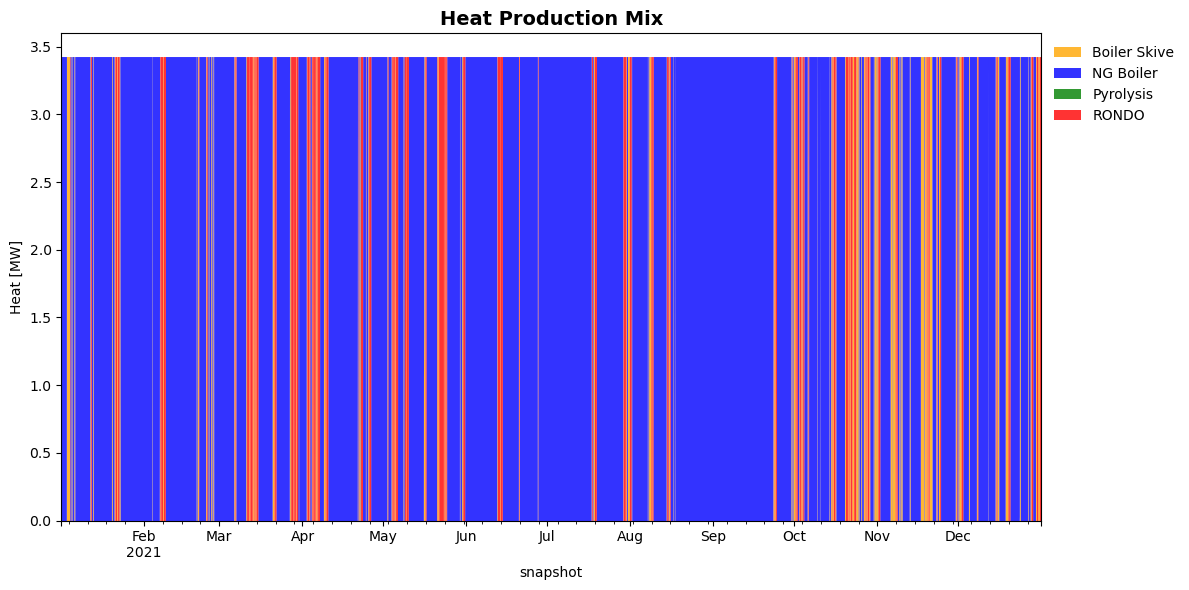

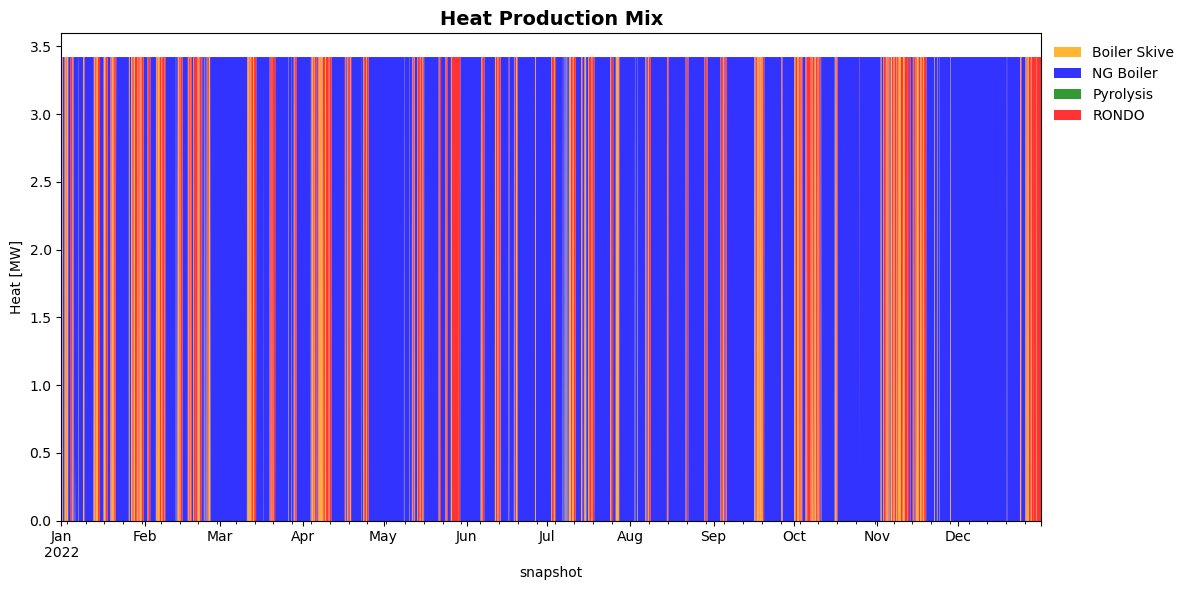

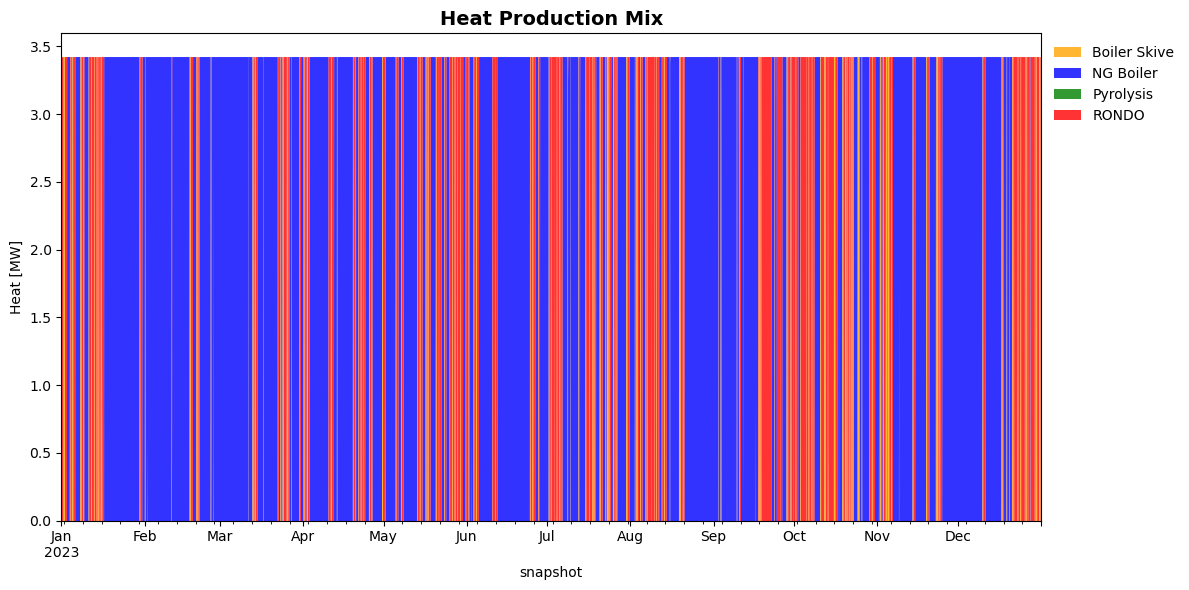

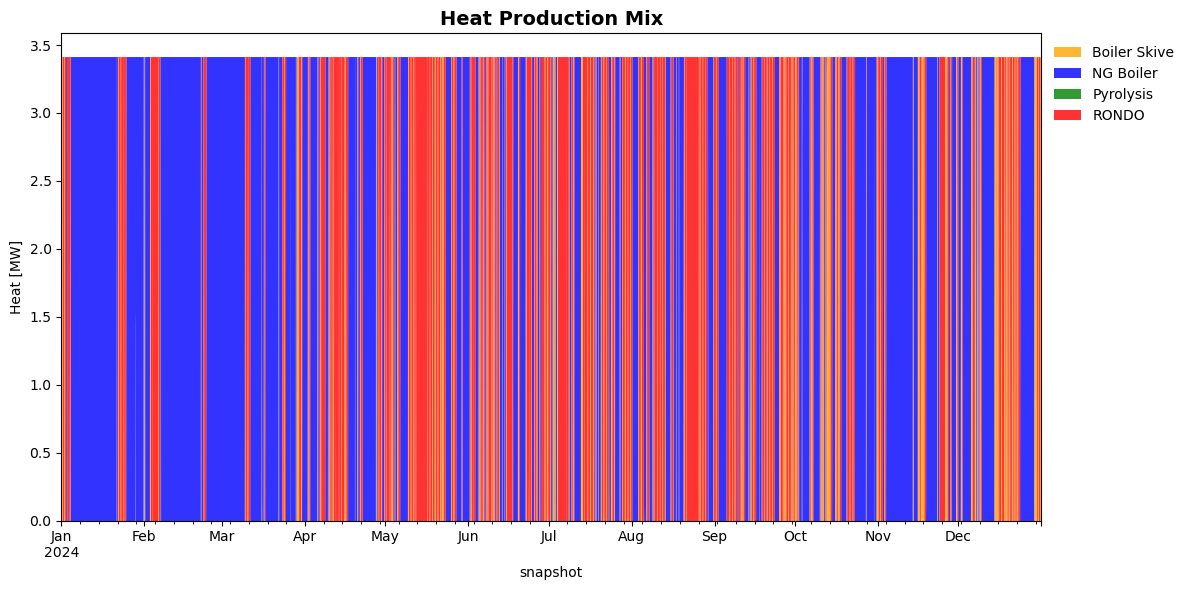

In [ ]:
plot_heat_summary(n21, load_name="Heat_Load_MT", title="Heat Production Mix", show_stats=True)

plot_heat_summary(n22, load_name="Heat_Load_MT", title="Heat Production Mix",show_stats=True)

plot_heat_summary(n23, load_name="Heat_Load_MT", title="Heat Production Mix", show_stats=True)

plot_heat_summary(n24, load_name="Heat_Load_MT", title="Heat Production Mix",show_stats=True)

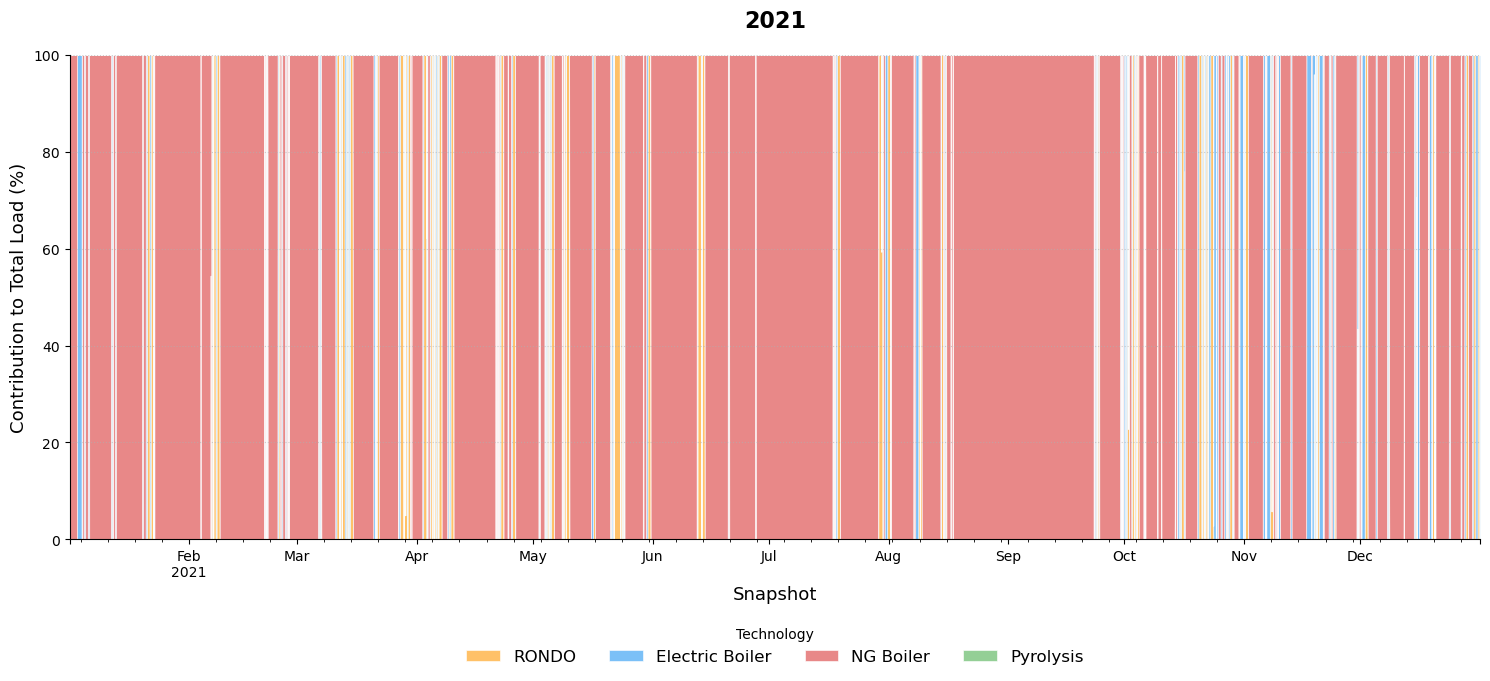

In [418]:
# 1. Gather data
heat_supply = pd.DataFrame({
    "RONDO": -n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"],
    "Electric Boiler": -n21.links_t.p1["Boiler_Skive"],
    "NG Boiler": -n21.links_t.p1["NG boiler"],
    "Pyrolysis": -n21.links_t.p1["pyrolysis"]
})

# 2. Normalize to percentages
heat_percent = heat_supply.div(heat_supply.sum(axis=1), axis=0) * 100

# 3. Define the professional palette
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 4. Create the plot
fig, ax = plt.subplots(figsize=(15, 7))

# FIX: Removed 'edgecolor' from the .plot.area call. 
# Pandas area plots are stacked by default.
heat_percent.plot.area(ax=ax, alpha=0.85, color=nice_colors, linewidth=0)

# OPTIONAL FIX: If you want the white lines back, 
# we can add them manually to avoid the AttributeError
for poly in ax.collections:
    poly.set_edgecolor('white')
    poly.set_linewidth(0.5)

# 5. Formatting
plt.title("2021", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Contribution to Total Load (%)", fontsize=13)
plt.xlabel("Snapshot", fontsize=13)
plt.ylim(0, 100) 

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=4, frameon=False, fontsize=12, title="Technology")

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

Text(0.5, 1.0, '2 MW Pyrolysis Plant')

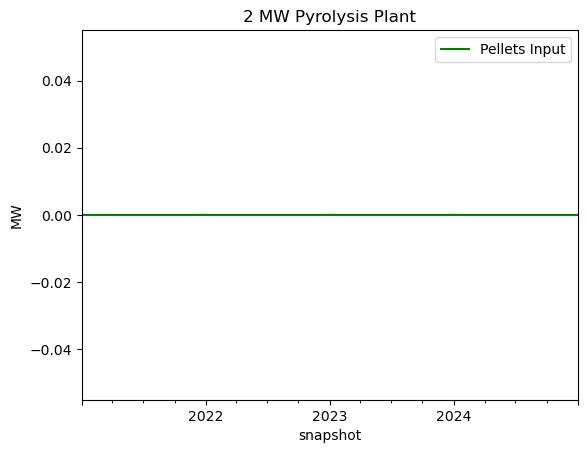

In [420]:
n21.links_t.p0["pyrolysis"].plot(color = "green", label = "Pellets Input")
plt.legend()
n22.links_t.p0["pyrolysis"].plot(color = "green")
n23.links_t.p0["pyrolysis"].plot(color = "green")
n24.links_t.p0["pyrolysis"].plot(color = "green")
plt.ylabel("MW")
plt.title("2 MW Pyrolysis Plant")

Text(0.5, 1.0, '2 MW Pyrolysis Plant')

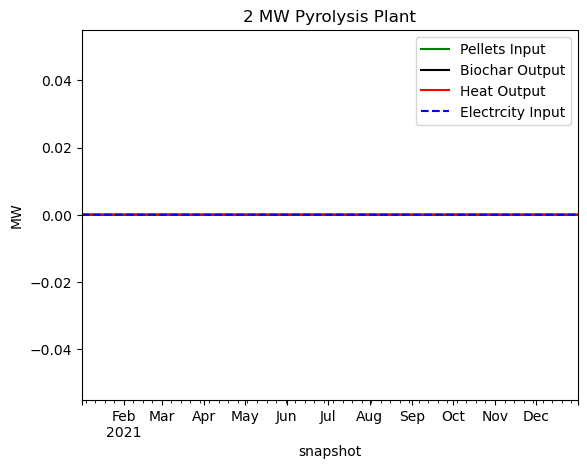

In [419]:
n21.links_t.p0["pyrolysis"].plot(color = "green", label = "Pellets Input")
(-n21.links_t.p2["pyrolysis"]).plot(color = "black", label = "Biochar Output")
(-n21.links_t.p1["pyrolysis"]).plot(color = "red", label = "Heat Output")
n21.links_t.p3["pyrolysis"].plot(color = "blue", label = "Electrcity Input",linestyle = "--")
plt.ylabel("MW")
plt.legend()
plt.title("2 MW Pyrolysis Plant")

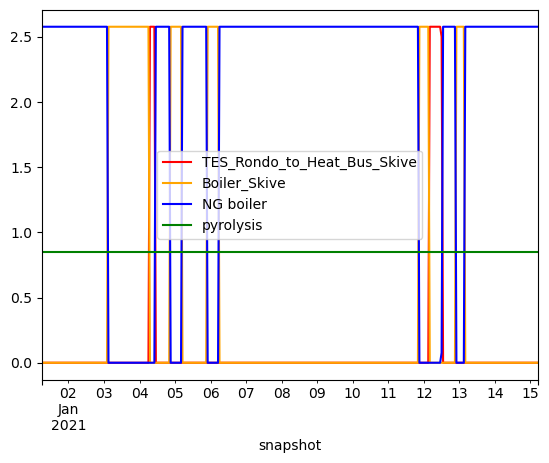

In [218]:
(-n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"][0:24*7*2]).plot(color = "red")
(-n21.links_t.p1["Boiler_Skive"][0:24*7*2]).plot(color = "orange")
(-n21.links_t.p1["NG boiler"][0:24*7*2]).plot(color = "blue")
(-n21.links_t.p1["pyrolysis"][0:24*7*2]).plot(color = "green")
plt.legend()

In [219]:
[n21.statistics.opex().sum()/1e6, n22.statistics.opex().sum()/1e6, n23.statistics.opex().sum()/1e6, n24.statistics.opex().sum()/1e6]

[-0.8905813846000005,
 -16.412308028490003,
 -1.6626645585900004,
 0.4459176973400004]

<Axes: ylabel='component,carrier'>

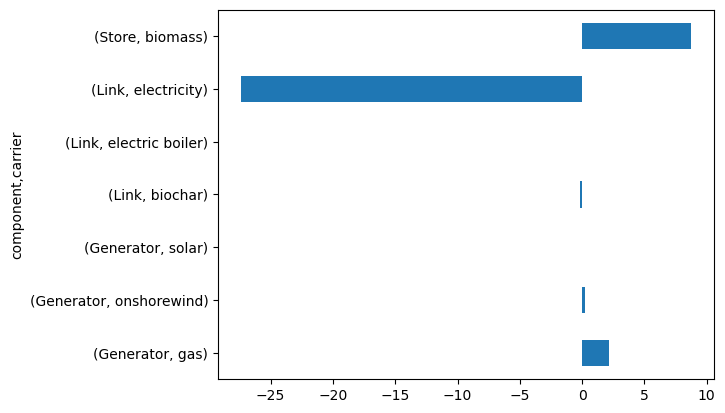

In [220]:
(n22.statistics.opex()/1e6).plot.barh()

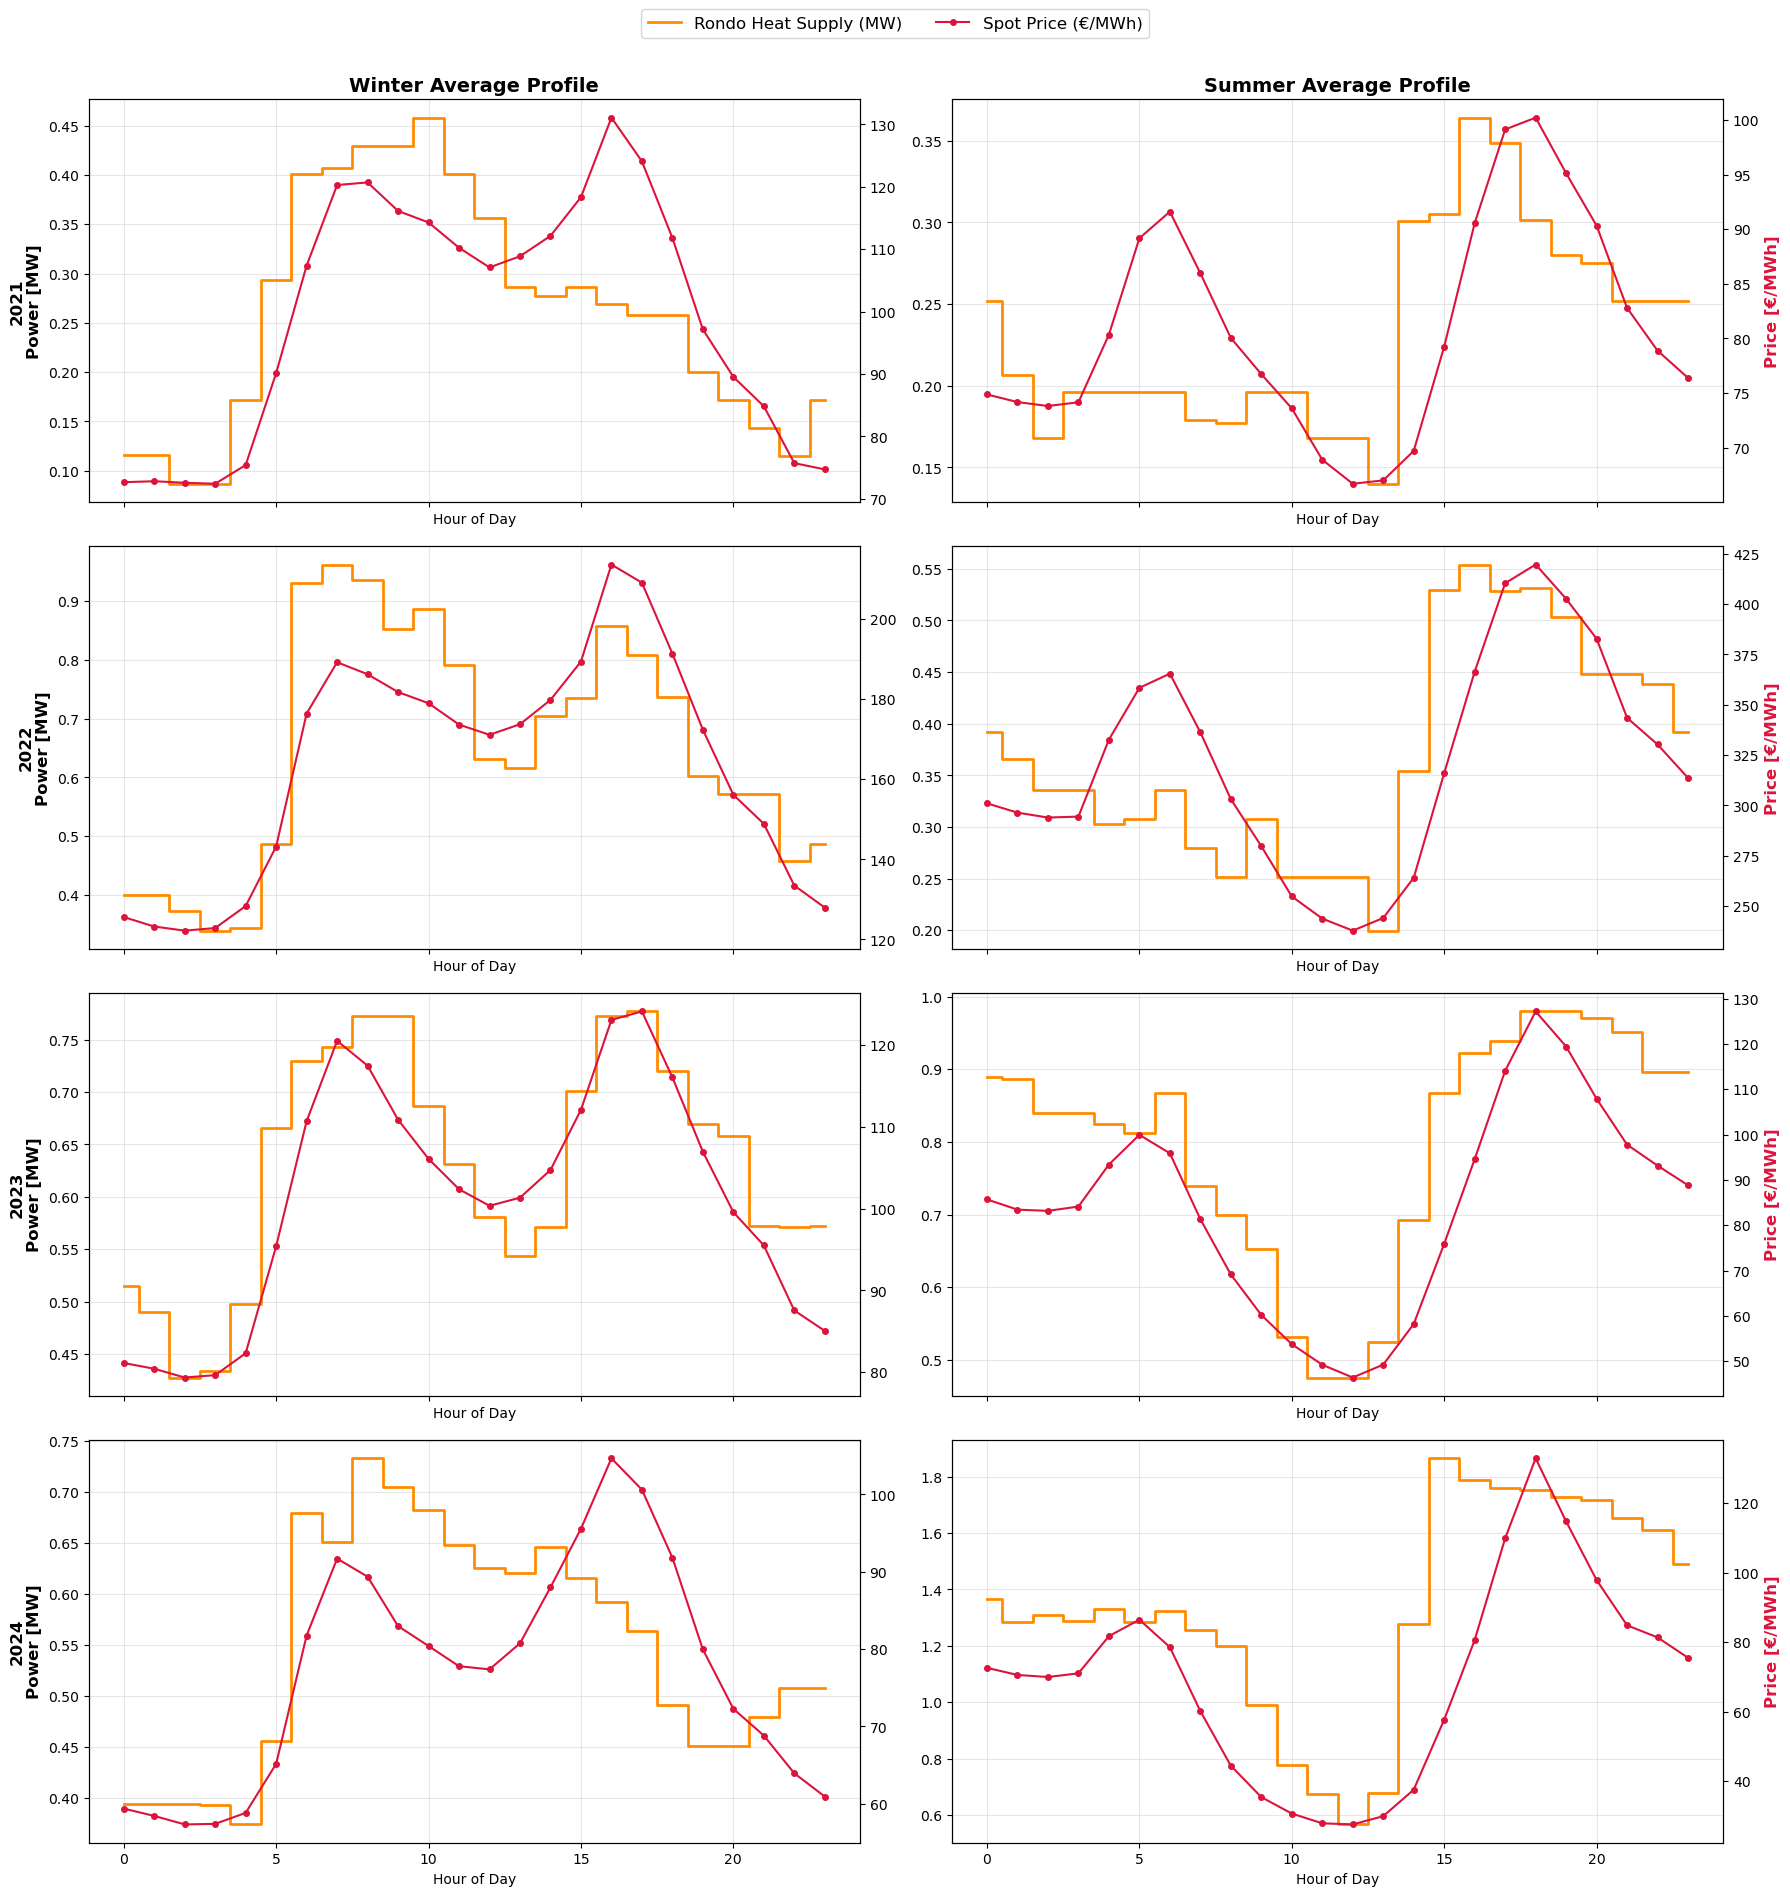

In [221]:
def plot_seasonal_profiles(networks, year_labels):
    fig, axes = plt.subplots(len(networks), 2, figsize=(18, 5 * len(networks)), sharex=True)
    
    for i, (label, n) in enumerate(zip(year_labels, networks)):
        # 1. Extract and Prep Data
        df = pd.DataFrame({
            'Price': n.buses_t.marginal_price["Greenlab"],
            #'Battery': n.storage_units_t.p["Skive_Battery"],
            #'Rondo_Heat': n.links_t.p0["Heat_Exchanger_Rondo"]
            'Rondo_Heat': -n.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"]
            #'Rondo_Heat': -n.links_t.p1["El_to_TES_Rondo"]
        })
        df['hour'] = df.index.hour
        df['month'] = df.index.month

        # 2. Filter Seasons
        winter = df[df['month'].isin([12, 1, 2])].groupby('hour').mean()
        summer = df[df['month'].isin([6, 7, 8])].groupby('hour').mean()

        for j, (data, season) in enumerate(zip([winter, summer], ["Winter", "Summer"])):
            ax = axes[i, j]
            ax2 = ax.twinx() # Secondary axis for Price

            # Plot Battery (Bars) and Rondo (Step)
            #ln1 = ax.bar(data.index, data['Battery'], color='steelblue', alpha=0.4, label='Battery Dispatch (MW)')
            ln2 = ax.step(data.index, data['Rondo_Heat'], color='darkorange', label='Rondo Heat Supply (MW)', where='mid', lw=2)
            
            # Plot Price (Line)
            ln3 = ax2.plot(data.index, data['Price'], color='crimson', label='Spot Price (€/MWh)', marker='o', markersize=4)

            # Labels and Titles
            if i == 0: ax.set_title(f"{season} Average Profile", fontsize=14, fontweight='bold')
            if j == 0: ax.set_ylabel(f"{label}\nPower [MW]", fontsize=12, fontweight='bold')
            if j == 1: ax2.set_ylabel("Price [€/MWh]", fontsize=12, fontweight='bold', color='crimson')
            
            ax.set_xlabel("Hour of Day")
            ax.grid(True, alpha=0.3)
            
            # 3. Create Unified Legend
            if i == 0 and j == 0:
                #lines = [ln1, ln2[0], ln3[0]]
                lines = [ln2[0], ln3[0]]
                labels = [l.get_label() for l in lines]
                fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run for your weather years
plot_seasonal_profiles([n21,n22,n23,n24], ["2021","2022","2023","2024"])

In [222]:
def plot_heat_production(n, title="Annual Heat Production"):
    """
    Plots the annual heat production for RONDO, Electric Boiler, 
    NG Boiler, and Pyrolysis from a PyPSA network.
    """
    # 1. Define the links we are looking for
    target_links = {
        #"RONDO": "Heat_Exchanger_Rondo",
        "RONDO": "TES_Rondo_to_Heat_Bus_Skive",
        "Electric Boiler": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis"
    }
    
    # 2. Extract values safely (handles missing links with 0.0)
    data = {}
    for label, link_name in target_links.items():
        if link_name in n.links.index:
            # Note: we use .get() or check existence to avoid KeyErrors
            # Summing p1 (output) and converting MW -> GWh
            data[label] = (-n.links_t.p1[link_name].sum()) / 1e3
        else:
            data[label] = 0.0
            
    annual_heat = pd.Series(data)
    total_gwh = annual_heat.sum()
    
    # Avoid division by zero if network is empty/unsolved
    if total_gwh == 0:
        print("Warning: Total heat production is 0. Check if the network is solved.")
        return
    
    # 3. Aesthetics & Sorting
    nice_colors = {'RONDO': '#FFB74D', 'Electric Boiler': '#64B5F6', 
                   'NG Boiler': '#E57373', 'Pyrolysis': '#81C784'}
    
    annual_heat_sorted = annual_heat.sort_values(ascending=False)
    plot_colors = [nice_colors[idx] for idx in annual_heat_sorted.index]
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, 
                  color=plot_colors, edgecolor='white', linewidth=1)

    # 5. Data Labels
    for bar in bars:
        height = bar.get_height()
        label_idx = annual_heat_sorted.index[bars.index(bar)]
        pct = (height / total_gwh * 100)
        
        ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
                f'{height:.1f} GWh\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=25)
    ax.set_ylabel("Total Heat Production [GWh]", fontsize=13)
    ax.set_xlabel("Technology", fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.6)
    
    plt.ylim(0, annual_heat_sorted.max() * 1.2)
    plt.tight_layout()
    plt.show()

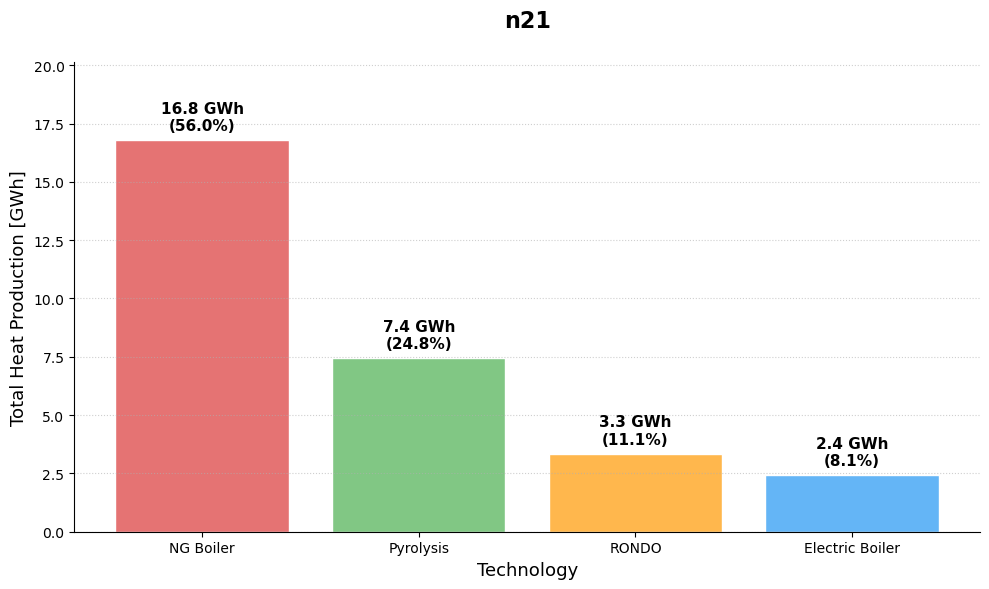

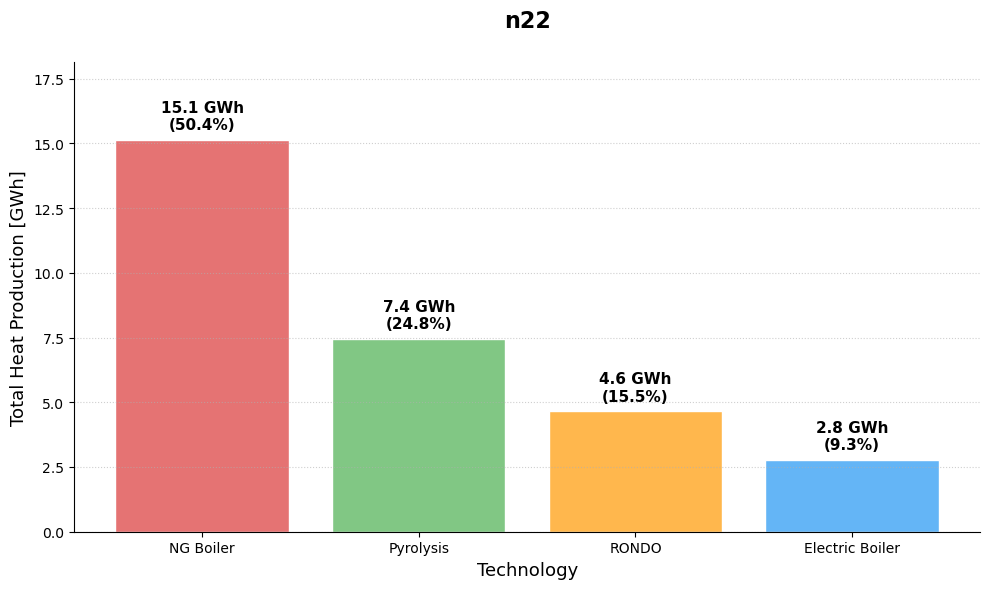

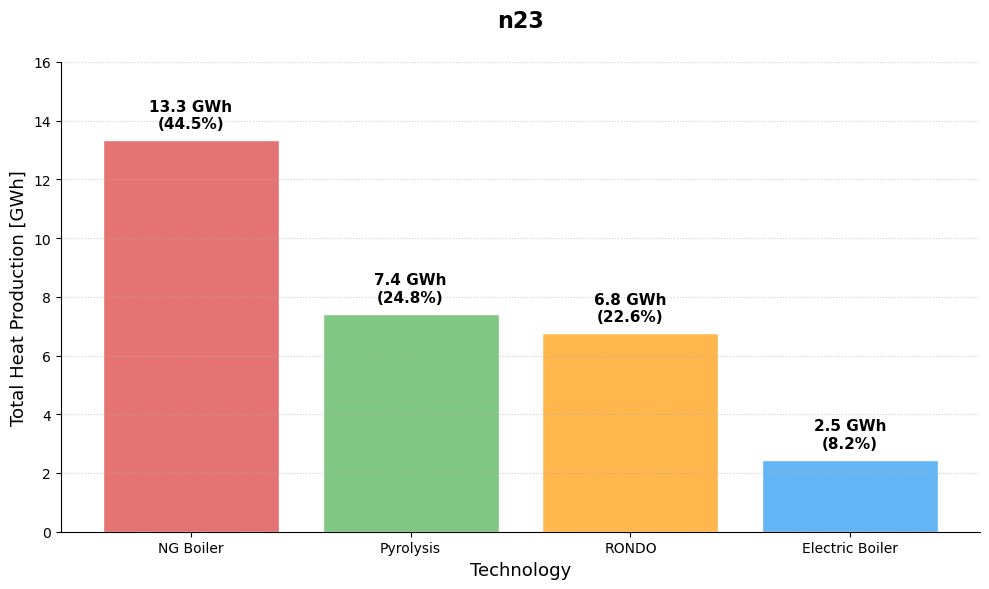

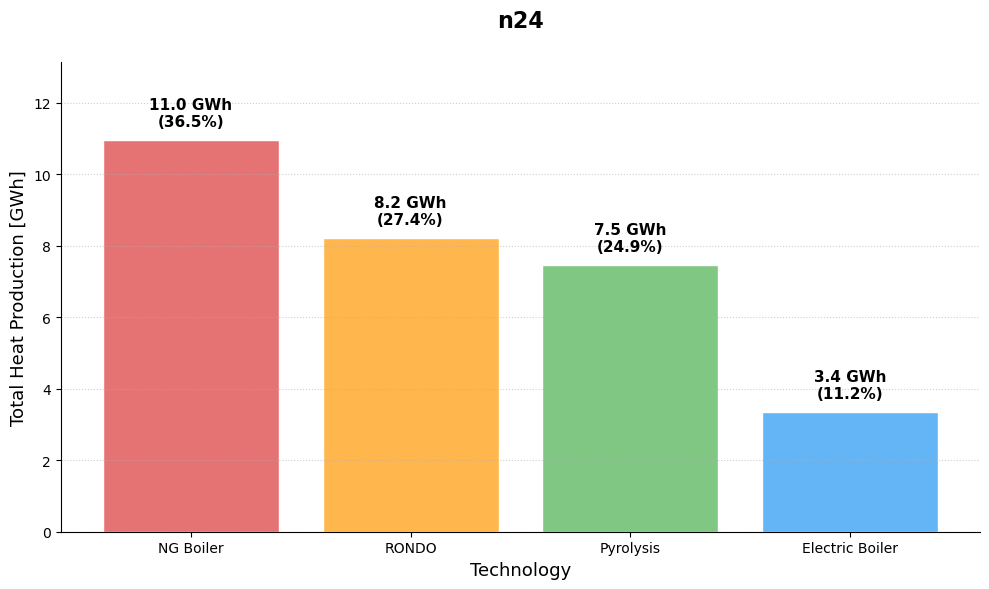

In [224]:
plot_heat_production(n21,title = "n21")
plot_heat_production(n22,title = "n22")
plot_heat_production(n23,title = "n23")
plot_heat_production(n24,title = "n24")

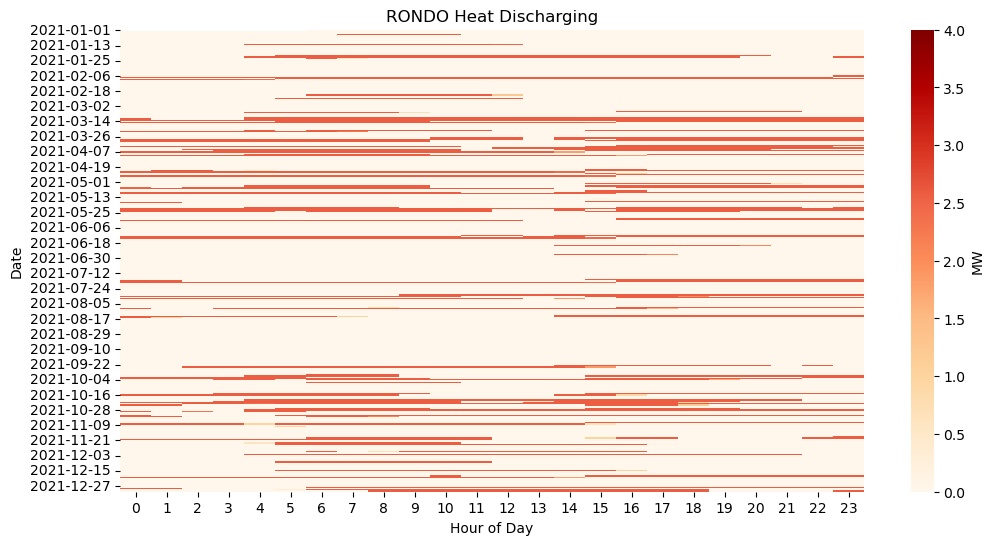

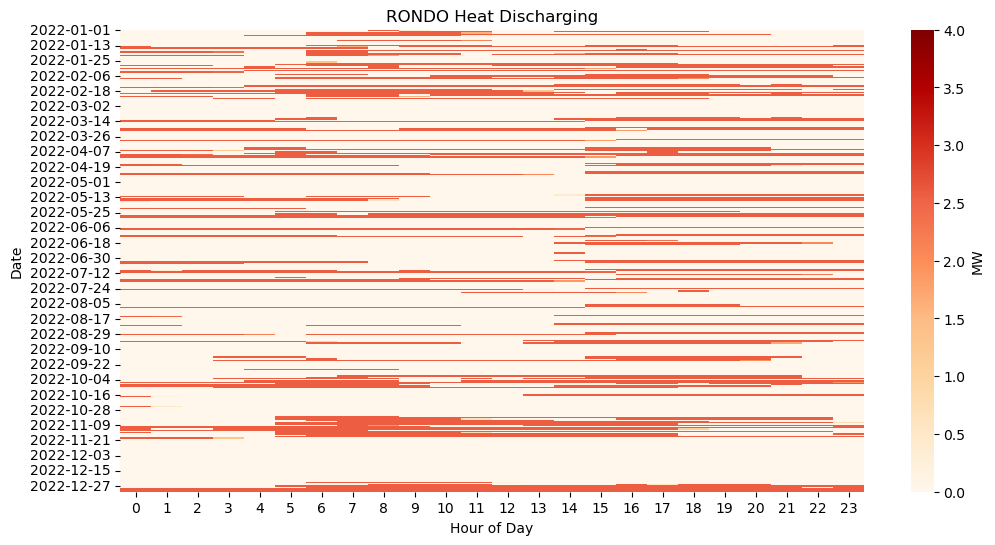

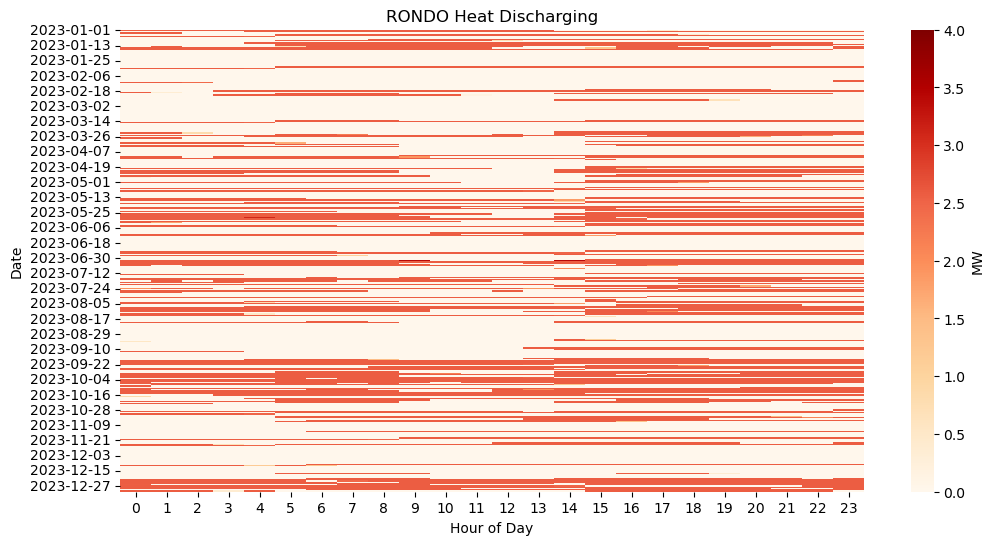

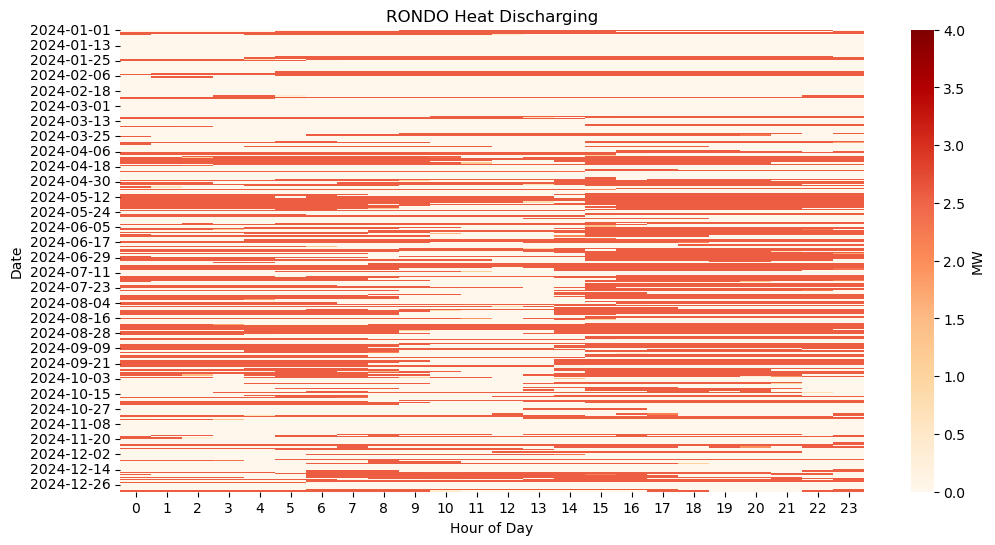

In [287]:

plot_pypsa_heatmap(-n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd",vmin= 0, vmax = 4)
                   
plot_pypsa_heatmap(-n22.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"],
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd",vmin= 0, vmax = 4)

plot_pypsa_heatmap(-n23.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd",vmin= 0, vmax = 4)

plot_pypsa_heatmap(-n24.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd",vmin= 0, vmax = 4)

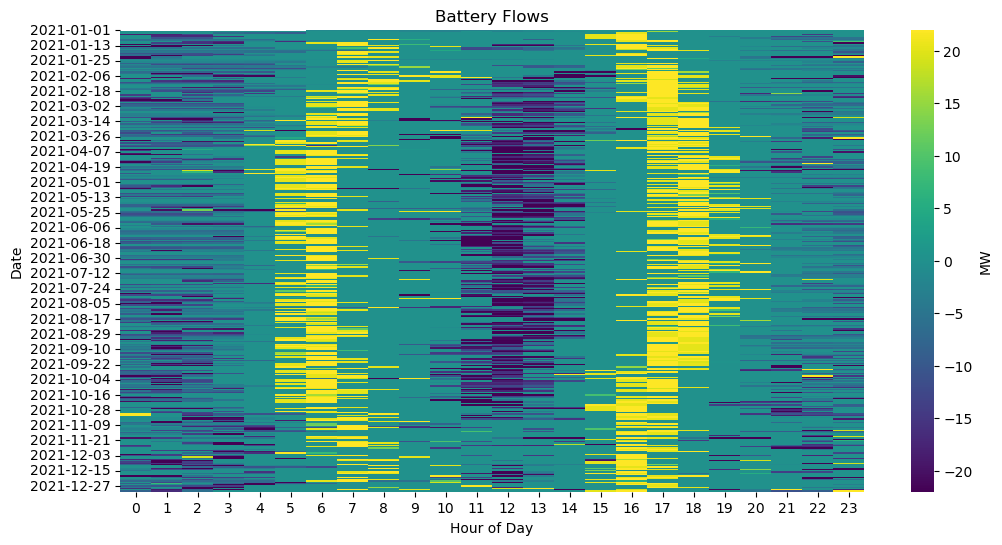

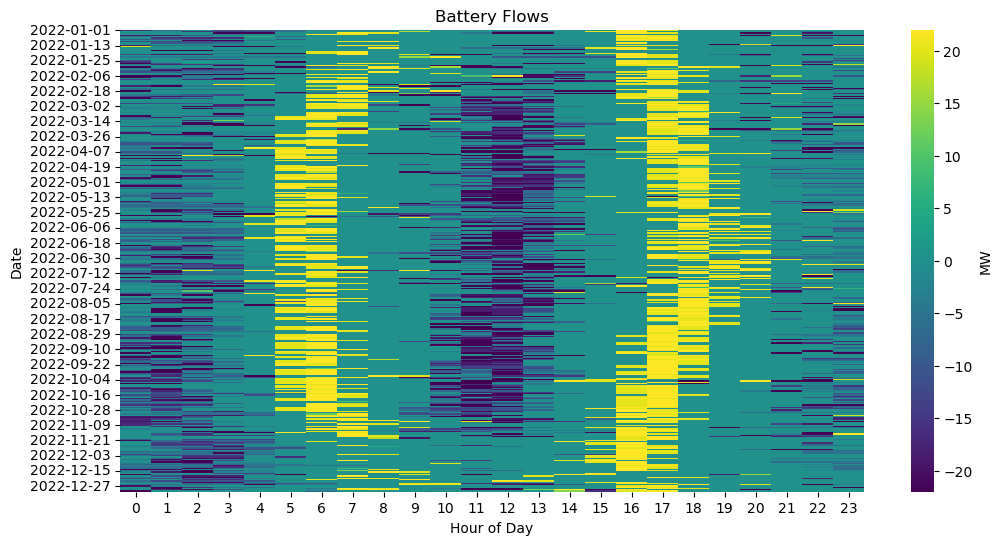

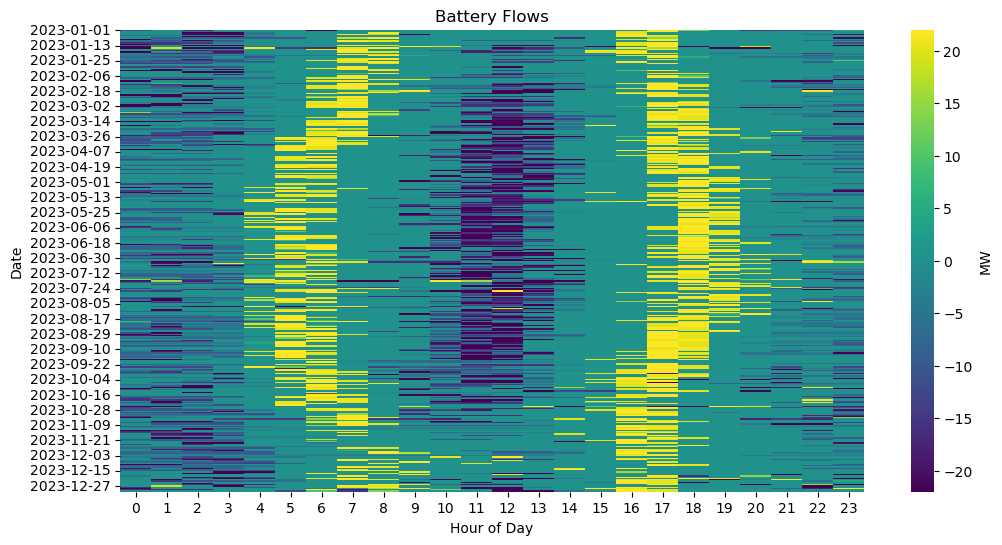

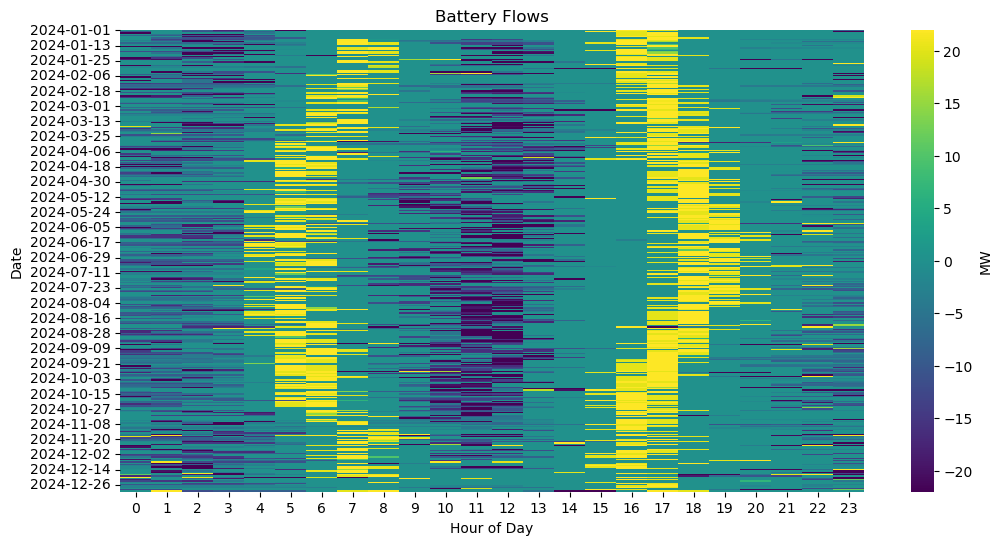

In [228]:
plot_pypsa_heatmap(n21.storage_units_t.p["Skive_Battery"], title="Battery Flows", unit="MW", cmap="viridis", ax=None, vmin=None, vmax=None)
plot_pypsa_heatmap(n22.storage_units_t.p["Skive_Battery"], title="Battery Flows", unit="MW", cmap="viridis", ax=None, vmin=None, vmax=None)
plot_pypsa_heatmap(n23.storage_units_t.p["Skive_Battery"], title="Battery Flows", unit="MW", cmap="viridis", ax=None, vmin=None, vmax=None)
plot_pypsa_heatmap(n24.storage_units_t.p["Skive_Battery"], title="Battery Flows", unit="MW", cmap="viridis", ax=None, vmin=None, vmax=None)

In [229]:
n21.stores["e_nom_opt"], n22.stores["e_nom_opt"], n23.stores["e_nom_opt"], n24.stores["e_nom_opt"]

(Store
 Grid_Store                     119660.803906
 Rondo_Concrete_Heat_Storage       100.000000
 Biomass Store                  500000.000000
 Biogas_Store                        0.000000
 Co2_Store                       20000.000000
 pellets store                    6492.000000
 biochar sequestred               8000.000000
 Name: e_nom_opt, dtype: float64,
 Store
 Grid_Store                     131574.260034
 Rondo_Concrete_Heat_Storage       100.000000
 Biomass Store                  500000.000000
 Biogas_Store                        0.000000
 Co2_Store                       20000.000000
 pellets store                    6480.000000
 biochar sequestred               8000.000000
 Name: e_nom_opt, dtype: float64,
 Store
 Grid_Store                     122378.790684
 Rondo_Concrete_Heat_Storage       100.000000
 Biomass Store                  500000.000000
 Biogas_Store                        0.000000
 Co2_Store                       20000.000000
 pellets store                    651

In [230]:
n21.statistics.opex()

component  carrier        
Generator  gas                1.051045e+06
           onshorewind        2.023601e+05
           solar              4.062244e+02
Link       biochar           -1.972801e+05
           electric boiler    2.988621e+03
           electricity       -1.072810e+07
Store      biomass            8.778000e+06
Name: objective, dtype: float64

In [231]:
n22.statistics.opex()

component  carrier        
Generator  gas                2.193406e+06
           onshorewind        2.243661e+05
           solar              4.316612e+02
Link       biochar           -1.974154e+05
           electric boiler    3.418009e+03
           electricity       -2.741451e+07
Store      biomass            8.778000e+06
Name: objective, dtype: float64

In [375]:
n23.statistics.opex()

component  carrier        
Generator  gas                8.208704e+05
           onshorewind        2.166444e+05
           solar              4.055023e+02
Link       biochar           -1.970185e+05
           electric boiler    3.024041e+03
           electricity       -1.128459e+07
Store      biomass            8.778000e+06
Name: objective, dtype: float64

In [232]:
def audit_network_carriers(n):
    """
    Checks all major PyPSA components for missing or default carriers.
    """
    components_to_check = ["Generator", "Link", "Store", "Storage_Unit", "Load"]
    missing_audit = []

    print("--- PyPSA Carrier Audit ---")
    
    for comp_type in components_to_check:
        df = getattr(n, comp_type.lower() + "s")
        if df.empty:
            continue
            
        # Find components where carrier is empty string or NaN
        missing = df[df.carrier.isin(["", None]) | df.carrier.isna()]
        
        if not missing.empty:
            for name in missing.index:
                missing_audit.append({"Type": comp_type, "Name": name})
                print(f"⚠️ MISSING CARRIER: {comp_type} '{name}'")
        else:
            print(f"✅ {comp_type}s: All categorized.")

    if not missing_audit:
        print("\n🌟 Audit Passed: Your network is ready for Rolling Horizon analysis!")
    else:
        print(f"\n❌ Audit Failed: {len(missing_audit)} components need a carrier assigned.")
    
    return pd.DataFrame(missing_audit)

# Run the audit
# df_issues = audit_network_carriers(n)

In [233]:
df_issues = audit_network_carriers(n21)

--- PyPSA Carrier Audit ---
✅ Generators: All categorized.
✅ Links: All categorized.
✅ Stores: All categorized.
✅ Storage_Units: All categorized.
✅ Loads: All categorized.

🌟 Audit Passed: Your network is ready for Rolling Horizon analysis!


### Biogas Plant End of Year Load

In [296]:
    # Fixed Load for Biogas Plant
def biogas_plant_simple2(n):

        n.add("Store","Biomass Store",
            bus = "Biogas_Feedstock",
            e_nom = 500000 ,
            e_initial = 500000, # t
            e_min_pu = 0,
            e_cyclic = False,
            carrier = "biomass",
            marginal_cost = 21) # EUR/t } Glycerine + Energy Crops + Animal Slurry

        n.add("Link",
            "BiogasPlant",
            bus0 = "Biogas_Feedstock", # input: Feedstock
            bus1 = "Greenlab", # input: electrcity
            bus2 = "Heat_MT", # input: heat
            bus3 = "pellets", # output: Pellets
            bus4 = "Biogas", # ouptut: CH4 
            bus5 = "Co2", # output: Co2
            carrier = "BiogasPlant",
            p_nom_extendable = True,
            #p_nom = 30*2.09, # t/h
            #p_min_pu = 25/30,
            p_nom_max = 63, 
            p_min_pu = 0,
            p_max_pu = 1,
            capital_cost = costs.at["biogas","capital_cost"],
            efficiency =  -(0.02 + 0.008 + 0.02)/2.09, # el input (MW) } auxillary + dewatering + upgrading 
            efficiency2 = -(0.05 + 0.1)/2.09, # heat input (MW) } auxillary + upgrading
            efficiency3 =  0.12/2.09, # Pellets output (MW)) 
            efficiency4  = 1/2.09,  # Biogas (CH4) output (MW)
            efficiency5 = 0.1/2.09, # co2 (t/h)
        )

        
        n.add("Store", "Biogas_Store",
            bus = "Biogas",
            marginal_cost = 0,
            carrier = "methane",
            capital_cost = costs.at["methane storage tank incl. compressor", "capital_cost"],
            e_nom_extendable = True,
            )

        n.add("Store", "Co2_Store",
        bus = "Co2",
        carrier = "CO2",
        e_nom_extendable = True,
        #e_nom = 500e3 # t
        )

        ch4_load_profile = pd.Series(0.0, index=n.snapshots)
        ch4_load_profile.iloc[-1] = 200 * 1e3

        # 200 GWh, Annualy
        n.add("Load", "CH4_Demand",
        bus = "Biogas",
        p_set = ch4_load_profile,
        # p_set = 200*1e3/len(n.snapshots),
        carrier = "methane")

In [297]:
def build_network2(CO2_tax, p_import, p_export, NG_price, horizon, overlap):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    
    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    add_carriers(n)

    n.add("Carrier","BiogasPlant")
    n.add("Carrier", "methane_demand", units = "MW")


    n.add("Bus", "Greenlab", carrier="electricity")

    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")

    n.add("Bus", "NG", carrier="gas")

     # Heat & Solids
    #n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    #n.add("Bus", "Digestate", carrier = "digestate")
    
    #n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")
    

    add_grid(n, price_import = p_import, price_export = p_export)

    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")
    #n.add("Bus", "methanol_bus", carrier = "methanol")

    add_battery(n, P_nom=22, max_t=2, cyclic_operation=False)
    add_skive_generators(n, s_cf, w_cf)

    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)

    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)

    biogas_plant_simple2(n)
    #digestate_treatment(n)
    #add_electrolyser(n, P_elec = 12)
    add_SkyClean(n, CO2tax = CO2_tax)
    #add_methanolisation(n, p_min = 0.1)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals = True,
            solver_name="gurobi", 
            horizon=horizon, overlap = overlap)
    else:
        # Full Year Optimization
        n.optimize(assign_all_duals = True,
            solver_name="gurobi",)

    return n

In [ ]:
n21_annual_load_target = build_network2(CO2_tax = 80, p_import = import_price21, p_export = export_price21, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 10.50it/s]
INFO:linopy.io: Writing time: 6.48s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 76200 iterations and 10.80 seconds (11.29 work units)


INFO:gurobipy:Solved in 76200 iterations and 10.80 seconds (11.29 work units)


Optimal objective  2.353857759e+08


INFO:gurobipy:Optimal objective  2.353857759e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 271384 primals, 595287 duals
Objective: 2.35e+08
Solver model: available
Solver message: 2



### Rolling Horizon

In [364]:
n21.loads_t.p["CH4_Demand"].max() , n22.loads_t.p["CH4_Demand"].max() , n23.loads_t.p["CH4_Demand"].max() ,n24.loads_t.p["CH4_Demand"].max()


(22.84669865204478, 22.831050228310502, 22.831050228310502, 22.768670309653917)

In [362]:
n21.links_t.p0["BiogasPlant"].max(),n22.links_t.p0["BiogasPlant"].max(), n23.links_t.p0["BiogasPlant"].max(), n24.links_t.p0["BiogasPlant"].max()

(47.74960018263321, 47.716894977100665, 47.71689497710068, 47.58652094722678)

- since the biogas plant is not incetivized to build a storage and produce at higher rates, more than 22 MW
- it dosen´t build a store
- hence we assume that the biomass plant has a capacity of around [48 t/h]

- this is not signf